In [1]:
import pandas as pd 
#charger le dataset 
df =pd.read_csv("car_dataset.csv")

In [3]:
df.shape

(205, 26)

In [2]:
df.describe()


,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


<Axes: xlabel='enginesize', ylabel='price'>

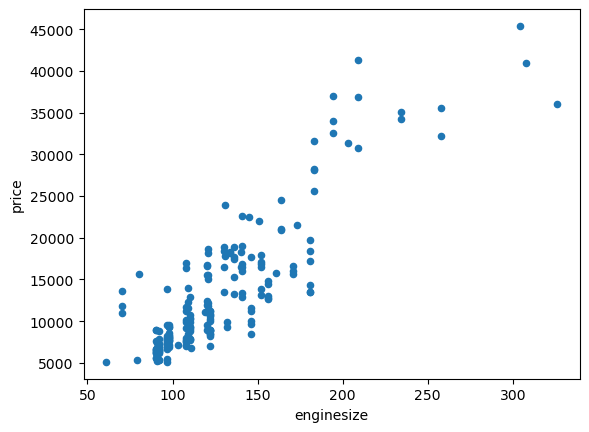

In [7]:
df.plot(x='enginesize' , y='price', kind='scatter')

Intercept (b0): -7741.765067166594
Coefficient (b1): 165.8445625610323
Mean Squared Error: 15465458.96590847
R² Score : 0.8040958796678975


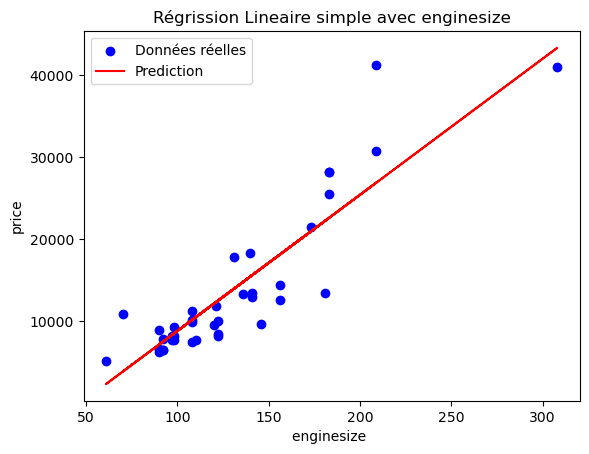

In [59]:
#importation des biblio necessaires
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,r2_score 
from sklearn.preprocessing import PolynomialFeatures 
import matplotlib.pyplot as plt 
import numpy as np

#Regression simple avec scikit-learn
#definer x and y variabble explicative et cible
x= df[['enginesize']]
y= df['price']

#separe train /test
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state =42)
#cree et entrainer le model
model = LinearRegression() 
model.fit(x_train , y_train ) 
#predire
y_pred=model.predict(x_test)
#afficher les coefficient
print("Intercept (b0):" , model.intercept_)
print("Coefficient (b1):", model.coef_[0])
#evaluation
mse =mean_squared_error(y_test,y_pred)
r2=r2_score(y_test ,y_pred) 
print("Mean Squared Error:",mse)
print("R² Score :" ,r2)

#visualisation la correlation globale
plt.scatter(x_test , y_test, color= 'blue' , label ='Données réelles' )
plt.plot(x_test , y_pred , color='red' , label='Prediction')
plt.xlabel("enginesize " )
plt.ylabel("price")
plt.title("Régrission Lineaire simple avec enginesize")
plt.legend()
plt.show() 


---- Régression multiple ----
Intercept (b0): -45654.55737012953
Coefficients (b1,b2,b3): [  52.12459274  -41.65628154  636.09776225    2.06659116   81.72507595
   45.62882281 -148.7407424    78.16453786]
MSE: 14461794.552489085
R²: 0.8168095013232901


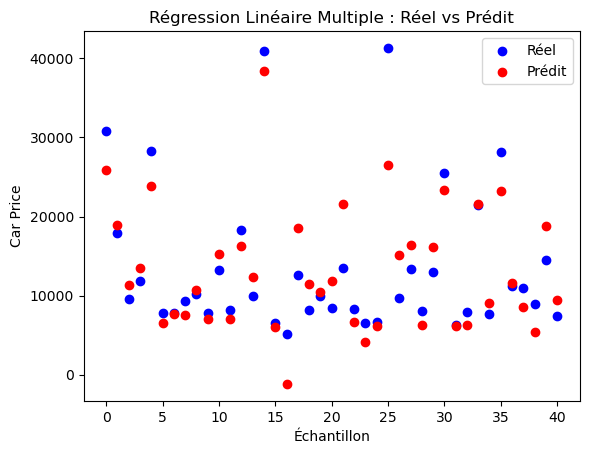

In [71]:
#regression multiple avec sckit-learn
#variable ex^licative x et cible y 
x_multiple = df[['wheelbase','carlength','carwidth','curbweight','enginesize','horsepower','citympg','highwaympg']]
y_multiple = df['price']
#train/test
x_train_m, x_test_m , y_train_m, y_test_m = train_test_split(x_multiple , y_multiple, test_size =0.2, random_state=42)
#cree et entrainer le model
model_multiple = LinearRegression() 
model_multiple.fit(x_train_m, y_train_m)
#predire
y_pred_m=model_multiple.predict(x_test_m)
#afficher
print("\n---- Régression multiple ----")
print("Intercept (b0):", model_multiple.intercept_)
print("Coefficients (b1,b2,b3):", model_multiple.coef_)
#evaluer le model
print("MSE:", mean_squared_error(y_test_m, y_pred_m))
print("R²:", r2_score(y_test_m, y_pred_m))

#visualisation l erreur indivuelle 
plt.scatter(range(len(y_test_m)), y_test_m, color='blue', label='Réel')
plt.scatter(range(len(y_pred_m)), y_pred_m, color='red', label='Prédit')
plt.xlabel("Échantillon")
plt.ylabel("Car Price")
plt.title("Régression Linéaire Multiple : Réel vs Prédit")
plt.legend()
plt.show()


Shape original x : (205, 1)
Shape polynomial x: (205, 3)

----- Régression Polynomiale -----
Intercept (b0): -9263.036157564027
Coefficients: [ 0.00000000e+00  1.86453884e+02 -6.15642440e-02]
MSE: 15637882.192005603
R²: 0.8019117595258544


C:\Users\asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


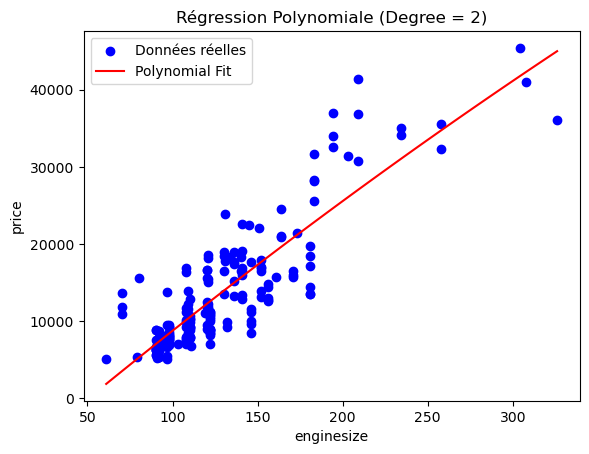

In [61]:
#Regression Polynomial avec scikit-learn 
#Transformer en polynomial features
poly = PolynomialFeatures(degree =2) #ici degre =2 
x_poly =poly.fit_transform(x) #sklearn cree auto 1,x,x²

print("Shape original x :", x.shape)
print ("Shape polynomial x:",x_poly.shape)
#train/test
x_train_p,x_test_p ,y_train_p,y_test_p = train_test_split(x_poly,y,test_size=0.2 ,random_state=42)
#entrainer le model
model=LinearRegression()
model.fit(x_train_p,y_train_p)
#prediction
y_pred_p = model.predict(x_test_p)
#evaluation 
print("\n----- Régression Polynomiale -----")
print("Intercept (b0):", model.intercept_)
print("Coefficients:", model.coef_)

mse=mean_squared_error(y_test_p,y_pred_p)
r2=r2_score(y_test_p,y_pred_p)

print("MSE:",mse)
print("R²:",r2)
#visualisation
X_range = pd.DataFrame(
    np.linspace(x.min().values[0], x.max().values[0], 100),
    columns=['enginesize']
)
x_range_poly =poly.transform(x_range)

y_range_pred =model.predict(x_range_poly)

plt.scatter(x,y,color='blue' ,label='Données réelles')
plt.plot(x_range,y_range_pred , color ='red' , label='Polynomial Fit')

plt.xlabel("enginesize")
plt.ylabel("price")
plt.title("Régression Polynomiale (Degree = 2)")
plt.legend()
plt.show()

In [63]:
#Regression linear simple from scratch
class SimpleLinearRegression:

    def __init__(self, learning_rate=0.01, iterations=2000):
        #taux d apprentissge et nombre de repition 
        self.lr = learning_rate
        self.iterations = iterations
        #prametre du model 
        self.weight = 0
        self.bias = 0
        #historique de l erreur 
        self.losses =[]

    #Mean Squared Error    
    def mse(self ,y, y_pred) :
        return np.mean((y-y_pred)**2)

    # fonction d'entraînement
    def fit(self, X, y):

        n = len(X)
        #prediction

        for i in range(self.iterations):

            # Prediction
            y_pred = self.weight * X + self.bias

            loss =self.mse(y,y_pred)
            self.losses.append(loss)

            # Calcul des gradients
            dw = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            # Update paramètres
            self.weight -= self.lr * dw
            self.bias -= self.lr * db

    # fonction prédiction
    
    def predict(self, X):
        return self.weight * X + self.bias


Weight : 6966.360205057605
Bias : 13276.710570731662
R2 Score: 0.7641291357806176
Final MSE: 14980261.40555132


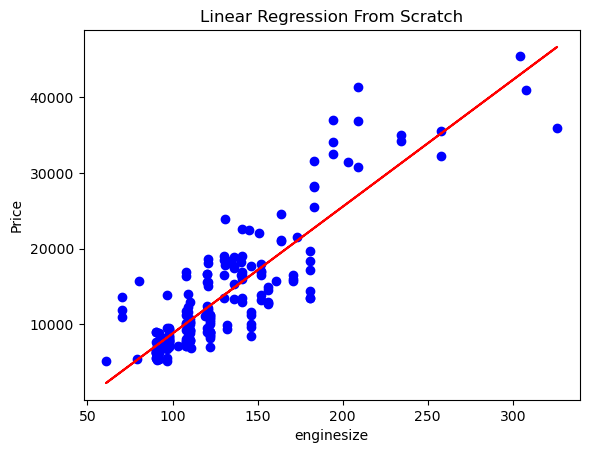

In [70]:
#Preparer les donnees
X = df['enginesize'].values
y = df['price'].values
#normalisation
X_norm = (X - np.mean(X)) / np.std(X)
#entrainer le model
model = SimpleLinearRegression(learning_rate=0.01, iterations=2000)

model.fit(X_norm, y)
#Prediction
y_pred = model.predict(X_norm)
#Resultat
print("Weight :", model.weight)
print("Bias :", model.bias)
print("R2 Score:", r2_score(y, y_pred))
final_mse = np.mean((y - y_pred)**2)
print("Final MSE:", final_mse)
#Visualistion 

plt.scatter(X, y, color="blue")
plt.plot(X, y_pred, color="red")
plt.xlabel("enginesize")
plt.ylabel("Price")
plt.title("Linear Regression From Scratch")
plt.show()

In [66]:
class MultipleLinearRegression :
    def __init__(self, learning_rate =0.01,iterations= 3000) :
        self.lr =learning_rate 
        self.iterations =iterations 
        self.weights =None
        self.bias=None
        self.losses=[] 
    def mse(self,y_multiple,y_pred ) :
        return np.mean((y_multiple-y_pred)**2)
        
    def fit(self,X_multiple,y_multiple) :
        #n_samples :nombre de ligne , n_features: nombre de colonnes
        n_samples, n_features =X_multiple.shape 
        #initialisation des poids a zero
        self.weights =np.zeros(n_features) 
        self.bias=0
        #boucle d apprentisge
        for i in range(self.iterations) :
            #calcule de la prediction
            y_pred =np.dot(X_multiple,self.weights)+self.bias 
            #Enrgstrement de l erreur actuelle 
            loss=self.mse(y_multiple,y_pred)
            self.losses.append(loss)
            #Calcul des gradiant

            dw=(-2/n_samples) *np.dot(X_multiple.T,(y_multiple-y_pred))
            db= (-2/n_samples ) *np.sum(y_multiple -y_pred) 
            #Mise a jour des parametre
            self.weights -=self.lr *dw 
            self.bias -= self.lr *db

    def predict (self , X_multiple) :
        #appication du model entraine sur de nouvelle donnes
        return np.dot(X_multiple,self.weights) + self.bias
            
        


Weights : [ 615.93025726 -738.38542729 1174.46237026 1401.02140454 3436.03868029
 2112.70487288 -447.04295832  552.8800297 ]
Bias : 13276.710570731664
Final MSE: 11339456.803883823
R2 Score: 0.821455220059159


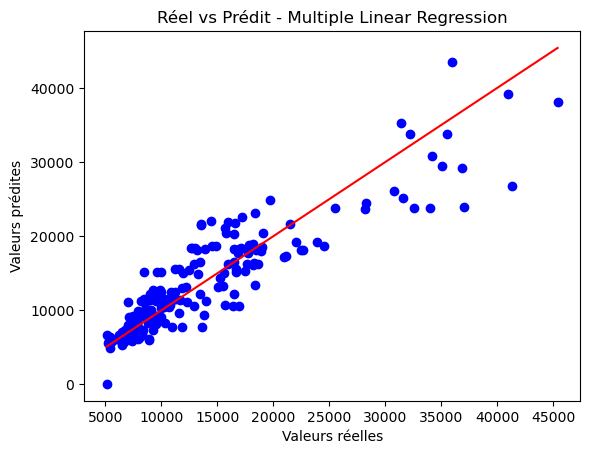

In [72]:
#les variable x et y 
X_multiple = df[['wheelbase','carlength','carwidth','curbweight','enginesize','horsepower','citympg','highwaympg']]
y_multiple = df['price']
#normalistaion des donnees
X_norm = (X_multiple -np.mean(X_multiple,axis =0)) / np.std(X_multiple,axis =0)
#creation du modele
model_multi = MultipleLinearRegression() 
#le model apprend les poid et le bias
model_multi.fit(X_norm , y_multiple )
#on predit les prit avec les donnes normalisees
y_pred_multi =model_multi.predict(X_norm)
#affichage
print("Weights :", model_multi.weights)
print("Bias :", model_multi.bias)
#evaluation du model
mse_final = np.mean((y_multiple - y_pred_multi)**2)
print("Final MSE:", mse_final)
#visualisation
print("R2 Score:", r2_score(y_multiple, y_pred_multi))
plt.scatter(y_multiple, y_pred_multi, color='blue')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit - Multiple Linear Regression")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')  # ligne parfaite

plt.show()

In [69]:
class PolynomialRegression:

    def __init__(self, learning_rate=0.01, iterations=4000):
        #taux d apprentissage et nombre d itersssion 
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        #stockage de l erreur
        self.losses = []
    #mean squared Error
    def mse(self, y, y_pred):
        return np.mean((y - y_pred)**2)
    #entrainement du model
    def fit(self, X, y):
        # n_samples → nombre de lignes
        # n_features → nombre de colonnes
        n_samples, n_features = X.shape
        #initialistion a zero
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.iterations):

            y_pred = np.dot(X, self.weights) + self.bias

            loss = self.mse(y, y_pred)
            self.losses.append(loss)
            #calcul des gradiant
            dw = (-2/n_samples) * np.dot(X.T, (y - y_pred))
            db = (-2/n_samples) * np.sum(y - y_pred)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    #prediction
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

MSE: 14986576.156519003
R2: 0.7640297072240821


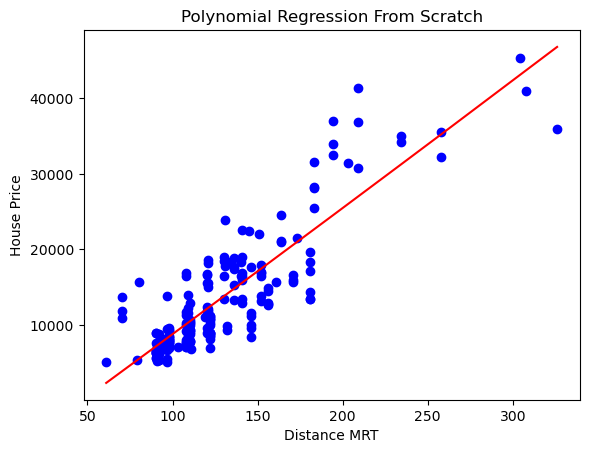

In [68]:
X = df['enginesize'].values
y = df['price'].values

degree = 2

X_poly = np.column_stack([X**i for i in range(1, degree+1)])

X_norm = (X_poly - np.mean(X_poly, axis=0)) / np.std(X_poly, axis=0)

model_poly = PolynomialRegression()

model_poly.fit(X_norm, y)

y_pred_poly = model_poly.predict(X_norm)

mse = np.mean((y - y_pred_poly)**2)

print("MSE:", mse)
print("R2:", r2_score(y, y_pred_poly))

sorted_index = np.argsort(X)

plt.scatter(X, y, color='blue')
plt.plot(X[sorted_index],
         y_pred_poly[sorted_index],
         color='red')

plt.xlabel("Distance MRT")
plt.ylabel("House Price")
plt.title("Polynomial Regression From Scratch")
plt.show()
